<div style="width: 100%; clear: both;">
<div style="float: left; width: 50%;">
<img src="http://www.uoc.edu/portal/_resources/common/imatges/marca_UOC/UOC_Masterbrand.jpg", align="left">
</div>
<div style="float: right; width: 50%;">
<p style="margin: 0; padding-top: 22px; text-align:right;">M2.981 · TFM · Aula 1</p>
<p style="margin: 0; text-align:right;">2024-2 · Màster universitari en Ciència de dades (Data science)</p>
<p style="margin: 0; text-align:right; padding-button: 100px;">Estudis d'informàtica, multimèdia i telecomunicació</p>
</div>
</div>
<div style="width:100%;">&nbsp;</div>
<div style="text-align: center; margin-top: 40px;">
    <h1>Aplicación para ayuda a la conducción con deep learning</h1>
</div>

### ARCHIVO 14: Programa principal main

Código que evalua vídeos e imágenes con los modelos previamente entrenados y en función de parámetros archivo config.

Código ejecutado en plataforma Visual Studio Code.

In [2]:
# Llibreries

from ultralytics import YOLO
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
from torchvision import transforms
import yaml
import torch.nn.functional as F
from PIL import Image

In [6]:
#Càrrega de paràmetres

# Arxiu Configuració
with open("config.yaml", "r") as file:
    config = yaml.safe_load(file)

#Funcionalitat
vehicles = config['functionality']['vehicles']
signs = config['functionality']['signs']
use_gpu = config['functionality']['use_gpu']

# Selecció de dispositiu
device = torch.device('cuda' if use_gpu and torch.cuda.is_available() else 'cpu')

# Models
if vehicles:
    model_veh = YOLO(config['model_paths']['detect_vehicles'])                             # Model detecció turismes i motos
    model_seg = YOLO(config['model_paths']['car_segment'])                                 # Model segmentació cotxes
    model_bra = torch.load(config['model_paths']['brake_classifier'], map_location=device) # Model classificació frens
    model_bra = model_bra.to(device).eval()        
        
    # Transformació per model_bra
    transform_frens = transforms.Compose([
        transforms.ToTensor(),
        transforms.Resize((224, 224)),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
                            ])

if signs:
    model_sin = YOLO(config['model_paths']['traffic_signs'])                             # Model detecció de semàfors i stops
    model_sem = torch.load(config['model_paths']['traffic_lights'], map_location=device) # Model classificació de semàfors
    model_sem = model_sem.to(device).eval()    
        
    # Transformació per model_sem
    transform_semafor = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
                            ])
    
# Paràmetres
# Models
det_veh_conf = config['model_det_veh_param']['det_veh_conf']
det_veh_iou = config['model_det_veh_param']['det_veh_iou']
det_sig_conf = config['model_det_sig_param']['det_sig_conf']
det_sig_iou = config['model_det_sig_param']['det_sig_iou']
seg_car_conf = config['model_seg_car_param']['seg_car_conf']
seg_car_iou = config['model_seg_car_param']['seg_car_iou']
class_brake = config['model_cla_bra_param']['class_brake']
# Alarma
height_max = config['set_up_vehicle']['height']
x_position = config['set_up_vehicle']['x_position']

In [4]:
# Entrada

picture = None
video = None

try:
    picture = cv2.imread(config['input']['picture'])
except Exception as e:
    print("No s'ha pogut carregar la imatge")
    
try:
    video = cv2.VideoCapture(config['input']['video'])
    if not video.isOpened():
        raise FileNotFoundError("No s'ha pogut obrir el vídeo.")
except Exception as e:
    print("No s'ha pogut carregar el vídeo")
    
pic = picture is not None
vid = video is not None

No s'ha pogut carregar el vídeo



0: 480x640 7 cars, 1 motorcycle, 16.6ms
Speed: 3.5ms preprocess, 16.6ms inference, 2.8ms postprocess per image at shape (1, 3, 480, 640)
True 672.336 801.0 1343.664 603 0.22
False 672.336 1256.0 1343.664 93 0.22
False 672.336 156.0 1343.664 65 0.22
False 672.336 1924.0 1343.664 473 0.22
False 672.336 343.5 1343.664 55 0.22
False 672.336 421.0 1343.664 55 0.22
False 672.336 1192.0 1343.664 57 0.22
False 672.336 1139.5 1343.664 50 0.22

0: 480x640 2 traffic lights, 17.8ms
Speed: 3.4ms preprocess, 17.8ms inference, 2.4ms postprocess per image at shape (1, 3, 480, 640)


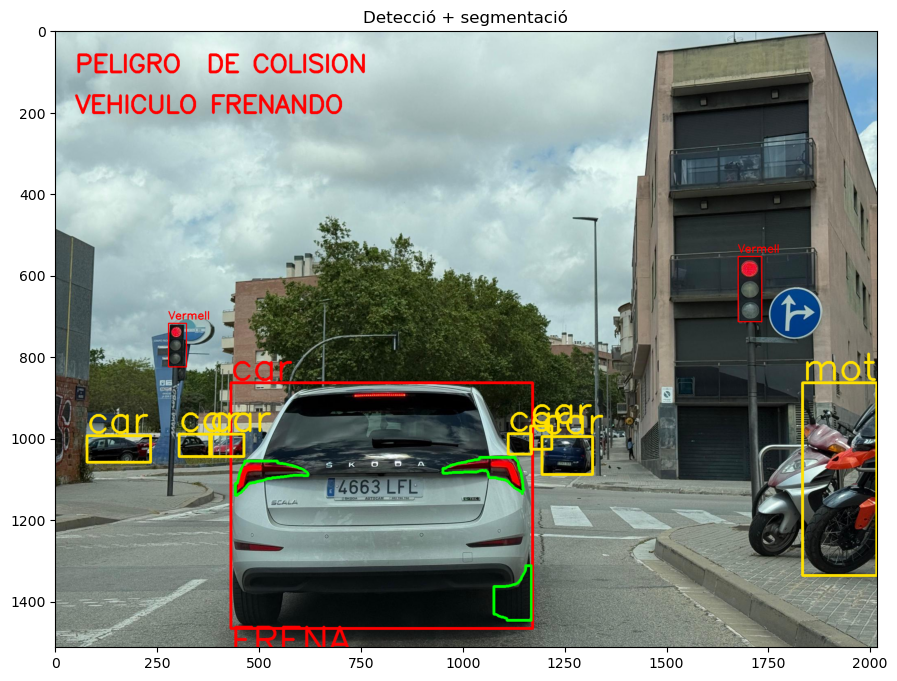

In [ ]:
# Imatge
if pic:
    
    frame = picture
    frame = cv2.imread("P8.jpg")
    
    # Vehicles
    if vehicles:
        
        # Detecció
        r_det_veh = model_veh(frame, conf=det_veh_conf, iou=det_veh_iou)[0]

        for box in r_det_veh.boxes:

            cls = int(box.cls[0])
            label = model_veh.names[cls]
            conf = box.conf[0]

            # Coordenades
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            x1, y1 = max(x1, 0), max(y1, 0)
            x2, y2 = min(x2, frame.shape[1]), min(y2, frame.shape[0])

            # Perill de col·lisió - Terç central? i Alçada bbox > 22%?
            width = frame.shape[1]
            height = frame.shape[0]

            center_x = (x1 + x2) / 2
            bbox_height = y2 - y1

            left_third = width/2 - (x_position * width / 2)
            right_third = width/2 + (x_position * width / 2)

            # Comprovació de perill
            perill = left_third <= center_x <= right_third and bbox_height > height_max * height
            print(perill, left_third, center_x, right_third, bbox_height, height_max)

            if perill:
                cv2.putText(frame, "PELIGRO  DE COLISION", (50, 100), # Missatge de perill per col·lisió
                    cv2.FONT_HERSHEY_SIMPLEX, 2, (0, 0, 255), 5)

            # Color de la bbox
            color = (0, 0, 255) if perill else (0, 225, 255)  # Vermell si perill, sinó groc

            
            # Dibuix bbox i text
            cv2.rectangle(frame, (x1, y1), (x2, y2), color, 5)
            label_text = f"{label}"
            cv2.putText(frame, label_text, (x1, y1 - 8),
                        cv2.FONT_HERSHEY_SIMPLEX, 3, color, 5)
   
            # Segmentació
            roi = frame[y1:y2, x1:x2]
            r_car_seg = model_seg(roi, conf=seg_car_conf, iou=seg_car_iou, verbose=False)[0]

            if r_car_seg.masks is not None and left_third <= center_x <= right_third: # Si segmenta, es mostren els resultats
                for i, mask in enumerate(r_car_seg.masks.data):
                    if i == 4 or i == 7 or i == 5:
                        mask_np = mask.cpu().numpy().astype("uint8") * 255
                        mask_resized = cv2.resize(mask_np, (x2 - x1, y2 - y1))

                        # Contorn
                        contours, _ = cv2.findContours(mask_resized, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
                        cv2.drawContours(roi, contours, -1, (0, 255, 0), 5) # Verd

                        # Retalla part segmentada
                        seg_img = roi.copy()
                        seg_img[mask_resized == 0] = 0

                        # Prepara per inferència
                        input_img = cv2.cvtColor(seg_img, cv2.COLOR_BGR2RGB)
                        input_img = cv2.resize(input_img, (224, 224))
                        input_tensor = transform_frens(input_img).unsqueeze(0).to(device)

                        with torch.no_grad():
                            output = model_bra(input_tensor)
                            prob = torch.sigmoid(output).item()
                            frenada = prob > config['model_cla_bra_param']['class_brake']

                        # Mostra resultat
                        status_text = "FRENA" if frenada else ""
                        color = (0, 0, 255) if frenada else (0, 255, 255)
                        cv2.putText(frame, status_text, (x1, y2 + 60),
                                    cv2.FONT_HERSHEY_SIMPLEX, 3, color, 6, cv2.LINE_AA)
                        if frenada:
                            cv2.putText(frame, "VEHICULO FRENANDO", (50, 200), # Missatge de frenada
                                cv2.FONT_HERSHEY_SIMPLEX, 2, (0, 0, 255), 5)
                        

    
    if signs:

        # Detecció
        r_det_sin = model_sin(frame, conf=det_sig_conf, iou=det_sig_iou)[0]

        # Noms de classes
        class_names = ["Scrap", "Verd", "Ignorar", "Vermell", "Groc"]


        for box in r_det_sin.boxes:

            cls = int(box.cls[0])
            conf = float(box.conf[0])
            
            # Coordenades
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            x1, y1 = max(x1, 0), max(y1, 0)
            x2, y2 = min(x2, frame.shape[1]), min(y2, frame.shape[0])

            roi = frame[y1:y2, x1:x2]

            if cls == 0:  # semàfor
                # Classificació amb EfficientNet
                img_pil = Image.fromarray(cv2.cvtColor(roi, cv2.COLOR_BGR2RGB))
                input_tensor = transform_semafor(img_pil).unsqueeze(0).to(device)

                with torch.no_grad():
                    output = model_sem(input_tensor)
                    probs = F.softmax(output, dim=1)
                    confidence, pred = torch.max(probs, dim=1)
                    confidence = confidence.item()
                    pred = pred.item()

                # Mostra resultat
                cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 0, 255), 2)
                cv2.putText(frame, class_names[pred], (x1, y1 - 10),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 0, 255), 2)                      
                                       
    # Correcció BGR a RGB
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # Mostra la imatge
    plt.figure(figsize=(12, 8))
    plt.imshow(frame_rgb)
    plt.title("Detecció + avís")
    plt.show()

In [37]:
# Imatge a tractar
frame = cv2.imread("foto1.jpg")

# Detecció
results_det = model_det(frame)[0]

# Per detecció mostra per pantalla
for box in results_det.boxes:

    cls = int(box.cls[0])
    label = model_det.names[cls]
    conf = box.conf[0]
    
    # Coordenades
    x1, y1, x2, y2 = map(int, box.xyxy[0])
    x1, y1 = max(x1, 0), max(y1, 0)
    x2, y2 = min(x2, frame.shape[1]), min(y2, frame.shape[0])

    # bbox + text
    cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 255), 5)
    label_text = f"{label} {conf:.2f}"
    cv2.putText(frame, label_text, (x1, y1 - 8),
                cv2.FONT_HERSHEY_SIMPLEX, 3, (0, 255, 255), 5)

    # Segmentació
    roi = frame[y1:y2, x1:x2] # ROI = Region of interest anomenat a la segmentació, regió de la imatge
    results_seg = model_seg(roi, conf=0.25, iou=0.4, verbose=False)[0]

    if results_seg.masks is not None: # Si segmenta, es mostren els resultats
        for i, mask in enumerate(results_seg.masks.data):
            if i == 4 or i == 7 or i == 5: # Únicament si són llums posteriors
                mask_np = mask.cpu().numpy().astype("uint8") * 255
                mask_resized = cv2.resize(mask_np, (x2 - x1, y2 - y1))
                                
                # Contorn
                contours, _ = cv2.findContours(mask_resized, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
                cv2.drawContours(roi, contours, -1, (0, 255, 0), 5) # Verd
                
                # Retalla part segmentada
                seg_img = roi.copy()
                seg_img[mask_resized == 0] = 0

                # Prepara per inferència
                input_img = cv2.cvtColor(seg_img, cv2.COLOR_BGR2RGB)
                input_img = cv2.resize(input_img, (224, 224))
                input_tensor = transform(input_img).unsqueeze(0).cuda()

                # Determina si frena o no
                with torch.no_grad():
                    output = model_bra(input_tensor)
                    prob = torch.sigmoid(output).item()
                    frenada = prob > 0.5

                # Mostra resultat
                status_text = "FRENA" if frenada else "NO FRENA"
                color = (0, 0, 255) if frenada else (0, 255, 255)
                cv2.putText(frame, status_text, (x1, y2 + 60),
                            cv2.FONT_HERSHEY_SIMPLEX, 3, color, 6, cv2.LINE_AA)

# Correcció BGR a RGB
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

# Mostra la imatge
plt.figure(figsize=(12, 8))
plt.imshow(frame_rgb)
plt.title("Detecció + segmentació")
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'foto1.jpg'

In [ ]:
# Vídeo a tractar
video_path = "Media/v2.mp4"
cap = cv2.VideoCapture(video_path)

# Sortida
out = cv2.VideoWriter("sortida_segmentadav4.mp4",
                      cv2.VideoWriter_fourcc(*'mp4v'),
                      cap.get(cv2.CAP_PROP_FPS),
                      (int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)), int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))))

# Per fotograma
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # DETECCIÓ de vehicles
    results_det = model_det(frame)[0]

    # Per detecció mostra per pantalla
    for box in results_det.boxes:

        cls = int(box.cls[0])
        label = model_det.names[cls]
        conf = box.conf[0]
    
        # Coordenades
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        x1, y1 = max(x1, 0), max(y1, 0)
        x2, y2 = min(x2, frame.shape[1]), min(y2, frame.shape[0])

        # bbox + text
        cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 255), 2)
        label_text = f"{label} {conf:.2f}"
        cv2.putText(frame, label_text, (x1, y1 - 8),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 255), 2)

        # Segmentació
        roi = frame[y1:y2, x1:x2] # ROI = Region of interest anomenat a la segmentació, regió de la imatge
        results_seg = model_seg(roi, verbose=False)[0]

        if results_seg.masks is not None: # Si segmenta, es mostren els resultats
            for i, mask in enumerate(results_seg.masks.data):
                if i == 4 or i == 7 or i == 5: # Únicament si són llums posteriors
                    mask_np = mask.cpu().numpy().astype("uint8") * 255
                    mask_resized = cv2.resize(mask_np, (x2 - x1, y2 - y1))
  
                    # Contorn
                    contours, _ = cv2.findContours(mask_resized, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
                    cv2.drawContours(roi, contours, -1, (0, 255, 0), 2) # Verd
                    
                    # Retalla part segmentada
                    seg_img = roi.copy()
                    seg_img[mask_resized == 0] = 0

                    # Prepara per inferència
                    input_img = cv2.cvtColor(seg_img, cv2.COLOR_BGR2RGB)
                    input_img = cv2.resize(input_img, (224, 224))
                    input_tensor = transform(input_img).unsqueeze(0).cuda()

                    # Determina si frena o no
                    with torch.no_grad():
                        output = model_bra(input_tensor)
                        prob = torch.sigmoid(output).item()
                        frenada = prob > 0.5

                    # Mostra resultat
                    status_text = "FRENA" if frenada else "NO FRENA"
                    color = (0, 0, 255) if frenada else (0, 255, 255)
                    cv2.putText(frame, status_text, (x1, y2 + 60),
                                cv2.FONT_HERSHEY_SIMPLEX, 1, color, 2, cv2.LINE_AA)

    # Escriu el frame al vídeo sortida
    out.write(frame)

# Tanca arxiu
cap.release()
out.release()
cv2.destroyAllWindows()


0: 384x640 4 cars, 164.3ms
Speed: 13.6ms preprocess, 164.3ms inference, 2.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 4 cars, 17.4ms
Speed: 2.7ms preprocess, 17.4ms inference, 3.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 4 cars, 20.0ms
Speed: 2.2ms preprocess, 20.0ms inference, 3.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 4 cars, 15.7ms
Speed: 2.0ms preprocess, 15.7ms inference, 2.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 5 cars, 16.1ms
Speed: 2.1ms preprocess, 16.1ms inference, 2.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 5 cars, 19.3ms
Speed: 2.0ms preprocess, 19.3ms inference, 3.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 5 cars, 16.2ms
Speed: 2.6ms preprocess, 16.2ms inference, 2.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 5 cars, 14.9ms
Speed: 2.2ms preprocess, 14.9ms inference, 2.9ms postprocess per image at shape (1, 3, 384, 640)

0: 3

error: OpenCV(4.10.0) D:\a\opencv-python\opencv-python\opencv\modules\highgui\src\window.cpp:1295: error: (-2:Unspecified error) The function is not implemented. Rebuild the library with Windows, GTK+ 2.x or Cocoa support. If you are on Ubuntu or Debian, install libgtk2.0-dev and pkg-config, then re-run cmake or configure script in function 'cvDestroyAllWindows'
